# Data Understanding:Telco Customer Churn

After defining the business problem and the project goals, the next step is to explore the raw data.

The goal of this phase is simple: to understand the dataset, check its quality, and identify potential issues before preparing the data and building machine learning models.

In [148]:
import pandas as pd
import matplotlib.pyplot as plt

In [149]:
df_raw = pd.read_csv("../data/raw/Telco-Customer-Churn.csv")

## Dataset Overview

In [150]:
df_raw.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


## Data Dimensions

In [151]:
df_raw.shape

(7043, 21)

## Feature Types

In [152]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [153]:
df_raw.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Missing Values

In [154]:
df_raw.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Duplicate Records

In [155]:
df_raw.duplicated().sum()

np.int64(0)

## Categorical Variables: Contract

In [156]:
df_raw["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [157]:
df_raw["Contract"].value_counts(normalize=True) * 100

Contract
Month-to-month    55.019168
Two year          24.066449
One year          20.914383
Name: proportion, dtype: float64

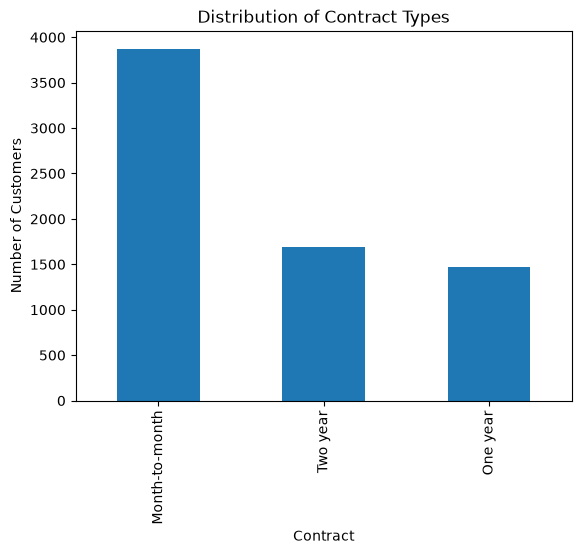

In [158]:
df_raw["Contract"].value_counts().plot(kind="bar")

plt.title("Distribution of Contract Types")
plt.xlabel("Contract")
plt.ylabel("Number of Customers")
plt.show()

More than half of the customers (55%) have a month-to-month contract, which means they are not committed for a long period.

This is an important observation because these customers can leave the company more easily than customers with one-year or two-year contracts. For this reason, the **Contract** variable is likely to be an important feature for predicting customer churn.

## Numerical Variables : Monthly Charges

In [159]:
df_raw["MonthlyCharges"].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

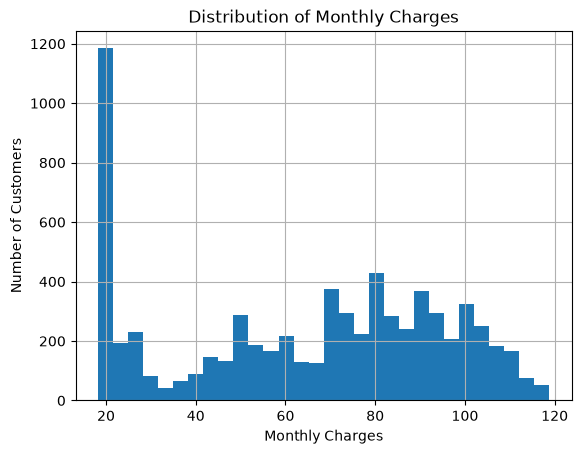

In [160]:
df_raw["MonthlyCharges"].hist(bins=30)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.show()

La distribution n'est pas unimodale : il y a un pic net autour de 20$ (probablement les clients avec un service minimal, type téléphone seul sans internet) puis une distribution plus diffuse au-delà de 40$. Cette forme multimodale suggère que `MonthlyCharges` est en réalité liée à des combinaisons de services souscrits logique à garder en tête pour le feature engineering, un simple montant ne raconte pas toute l'histoire sans le contexte des services associés.

In [161]:
df_raw["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [162]:
df_raw["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

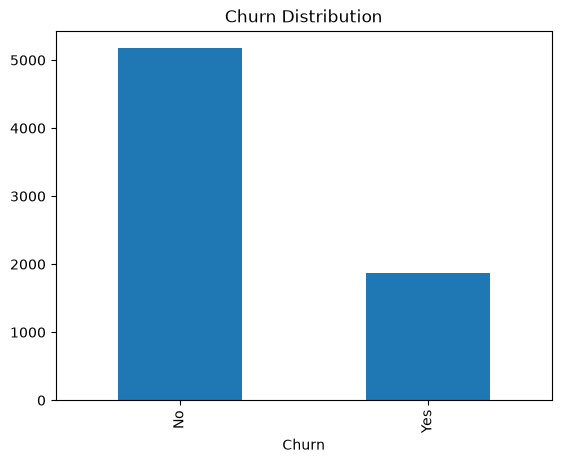

In [163]:
df_raw["Churn"].value_counts().plot(kind="bar")
plt.title("Churn Distribution")
plt.show()

## Contract vs Churn

In [164]:
pd.crosstab(df_raw["Contract"], df_raw["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [165]:
pd.crosstab(df_raw["Contract"], df_raw["Churn"], normalize="index") * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


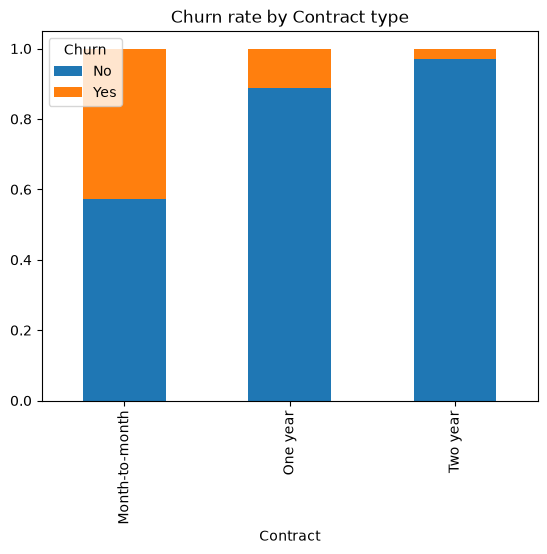

In [166]:
pd.crosstab(df_raw["Contract"], df_raw["Churn"], normalize="index").plot(kind="bar", stacked=True)

plt.title("Churn rate by Contract type")
plt.show()

The relationship observed earlier is clearly confirmed by the numbers: 42.7% of customers with a month-to-month contract churn, compared to 11.3% for one-year contracts and only 2.8% for two-year contracts.

The difference is very large. The type of contract is therefore likely one of the most important variables for predicting customer churn in this dataset.

## PaymentMethod vs Churn

In [167]:
pd.crosstab(df_raw["PaymentMethod"], df_raw["Churn"])

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


In [168]:
pd.crosstab(df_raw["PaymentMethod"], df_raw["Churn"], normalize="index") * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


The payment method "Electronic check" stands out clearly, with a churn rate of 45.3%, compared to 15% to 19% for the other payment methods (automatic bank transfer, credit card automatic payment, and mailed check).

Customers using automatic payments (bank transfer or credit card) show the lowest churn rates. This is likely because these payment methods require less active effort from the customer, which reduces friction and may lower the chances of reconsidering the subscription.

This pattern is worth further investigation, especially when combined with the type of contract, to see if the effect remains strong in a multivariate context.

## InternetService vs Churn

In [169]:
pd.crosstab(df_raw["InternetService"], df_raw["Churn"], normalize="index") * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


Customers with fiber optic churn almost twice as much (41.9%) as DSL customers (19%) and much more than customers without internet service (7.4%).

At first glance, this may seem counterintuitive for a premium service. However, this is a known pattern in this dataset. Fiber optic customers are likely paying higher prices and may also experience more service-related issues.

This hypothesis should be further investigated by comparing it with `MonthlyCharges` to better understand the impact of pricing on churn.

## MonthlyCharges vs Contract

In [170]:
df_raw.groupby("Contract")["MonthlyCharges"].mean()

Contract
Month-to-month    66.398490
One year          65.048608
Two year          60.770413
Name: MonthlyCharges, dtype: float64

The average monthly charges are quite similar across the three contract types (around $60 to $66). Therefore, the difference in churn observed earlier cannot be explained simply by price differences.

It is more likely that the contract commitment itself (how easy it is for customers to leave) is the main factor, rather than the level of monthly charges.

## Outliers

In [171]:
df_raw[["tenure", "MonthlyCharges", "TotalCharges"]].describe()

,tenure,MonthlyCharges
count,7043.000000,7043.000000
mean,32.371149,64.761692
std,24.559481,30.090047
min,0.000000,18.250000
25%,9.000000,35.500000
50%,29.000000,70.350000
75%,55.000000,89.850000
max,72.000000,118.750000


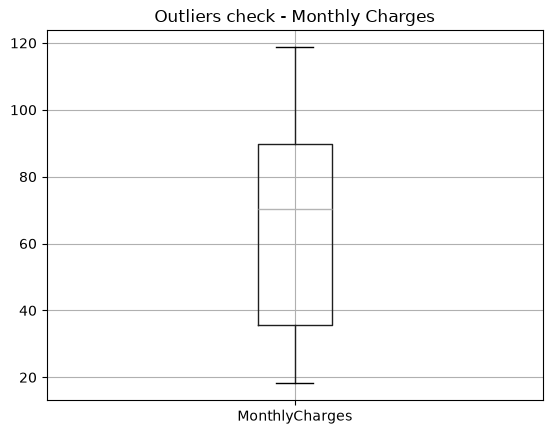

In [172]:
df_raw.boxplot(column="MonthlyCharges")
plt.title("Outliers check - Monthly Charges")
plt.show()

The boxplot does not show any outliers outside the whiskers. The distribution of `MonthlyCharges` is spread out but remains within a reasonable range (from $18 to $119), with no extreme values that need to be treated.

## Conclusion

The dataset is generally clean and usable, with only one clear issue: the `TotalCharges` variable, which requires proper handling during the data preparation phase.

The exploratory analysis has already revealed several important patterns. In particular, `Contract` and `MonthlyCharges` show strong potential relationships with customer churn, suggesting that customer commitment level and pricing structure are likely key drivers of churn behavior.

Overall, the dataset is of good quality and suitable for machine learning, but further analysis will be needed to confirm these early insights in a multivariate context.